# Two steps neural network 
Time and diffusive parameters

In [30]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions3D import getModel, kCrossVal, transfBestparam, import_data, normalization
from time import perf_counter
import pandas
import pickle
import os
from itertools import product
import keras
import tensorflow as tf

In [31]:
# reproducibility
seed=42
np.random.seed(seed)

keras.utils.set_random_seed(seed)

tf.random.set_seed(seed)

## Data preparation

In [32]:
file_path_D = os.path.join("..", "..", "Diffusion\DATA", "Discretizations_time.txt")
file_path_diff = os.path.join("..", "..", "Diffusion\DATA", "Discretizations.txt")

Discretizations= np.loadtxt(
    file_path_D
).astype(
    int
)

#Discr= np.loadtxt(
#    file_path_diff
#).astype(
#    int
#)
Discr=np.array([46])

In [33]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_HF = os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_HF.mat")
(reaction_HF_test, U_HF_test, t_HF_test) = import_data(file_path_HF)
t_HF_test=t_HF_test.T
U_HF_test = U_HF_test[:, :, 44,44]

In [34]:
########################     NORMALIZATION  #########################
# Input

reaction_HF_test = normalization(reaction_HF_test)
t_HF_test=normalization(t_HF_test)
U_HF_test=normalization(U_HF_test)


In [35]:
#########################     TRAIN SET      ##########################
NepoLF = 1000  # number of epochs for first NN: NN_LF
NepoHF = 1000  # number of epochs for second NN: NN_HF

Nlf=200
n_HF=100
#Nlf = np.array([100,150,200])
#n_HF=np.array([50,75,100,150])

In [36]:
# TRANSFORMATION

permutation1 = np.random.permutation(len(reaction_HF_test))
permutation2 = np.random.permutation(len(t_HF_test))

reaction_HF = reaction_HF_test[permutation1][0:n_HF]
t_HF = t_HF_test[permutation2][0:n_HF]

grid1, grid2 = np.meshgrid(reaction_HF, t_HF)
reaction_HF = np.column_stack((grid1.ravel(), grid2.ravel()))
reaction_HF_test = np.array(list(product(reaction_HF_test.flatten(), t_HF_test.flatten())))

reaction_HF=np.c_[reaction_HF, np.abs(np.sin(3.5*np.pi*reaction_HF[:, 1])),np.ones(reaction_HF.shape[0])]
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(3.5*np.pi*reaction_HF_test[:, 1])),np.ones(reaction_HF_test.shape[0])]

##
p1, p2 = np.meshgrid(permutation1[0:n_HF], permutation2[0:n_HF])
permutation = np.column_stack((p1.ravel(), p2.ravel()))
U_HF = U_HF_test[permutation[:,0],permutation[:,1]] 
row, col = U_HF_test.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_HF_test = U_HF_test.flatten()[comb]
##

In [37]:
U_LF_list = []
U_HF_list = []

diffusion=[5]

r2_HF_df = pandas.DataFrame(columns=['Discretization','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','MSE'])  # dataframe which stores LF MSE

********************  # Nb. nodes = 801  ********************
********************  # Diff: = 5  ********************


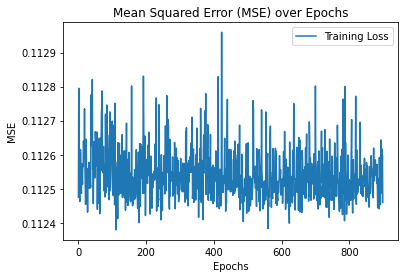

1252/1252 [==============================] - 3s 2ms/step

LF Model:
Test MSE: 0.11178127668215714
R^2: -0.001417190205522667
157/157 [==============================] - 0s 3ms/step


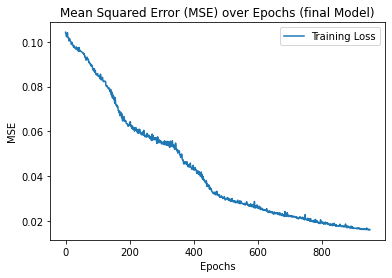

1252/1252 [==============================] - 3s 2ms/step
Elapsed time:  198.9879699999001

HF Model:
Test MSE: 0.0037841295685008955
R^2: 0.9664061159461782
26/26 [==============================] - 0s 2ms/step


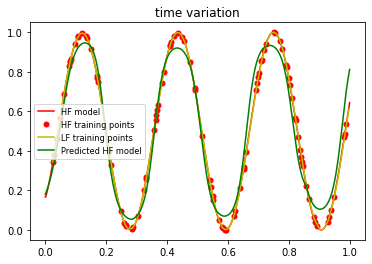

2/2 [==============================] - 0s 0s/step


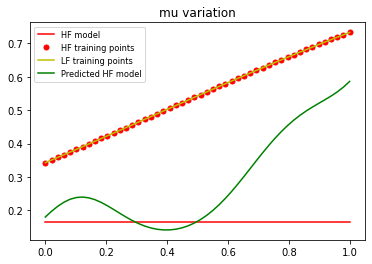

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_5152\3627381309.py:225: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_5152\3627381309.py:227: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_5152\3627381309.py:229: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_5152\3627381309.py:231: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 81  ********************
********************  # Diff: = 5  ********************


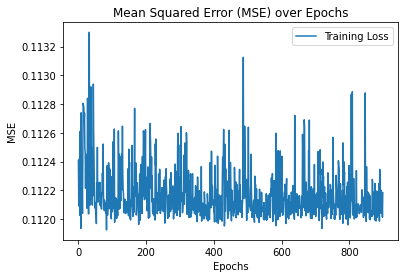

127/127 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.11197959360274991
R^2: -8.453136091368663e-05
157/157 [==============================] - 0s 2ms/step


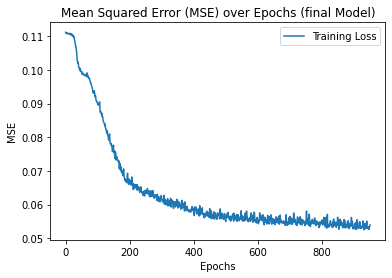

1252/1252 [==============================] - 2s 2ms/step
Elapsed time:  194.10264830011874

HF Model:
Test MSE: 0.048275881470484464
R^2: 0.5714273691326126
26/26 [==============================] - 0s 2ms/step


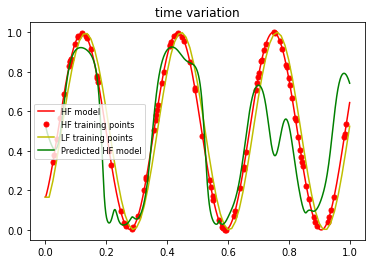

2/2 [==============================] - 0s 0s/step


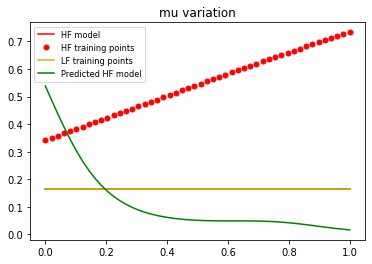

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_5152\3627381309.py:225: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_5152\3627381309.py:227: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_5152\3627381309.py:229: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_5152\3627381309.py:231: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 41  ********************
********************  # Diff: = 5  ********************


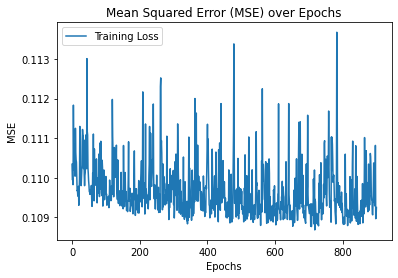

65/65 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.10711201580412569
R^2: 0.04600975031061849
157/157 [==============================] - 0s 2ms/step


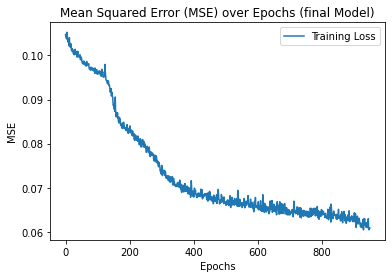

1252/1252 [==============================] - 3s 2ms/step
Elapsed time:  177.1830384999048

HF Model:
Test MSE: 0.054146005027219175
R^2: 0.5193149225113212
26/26 [==============================] - 0s 2ms/step


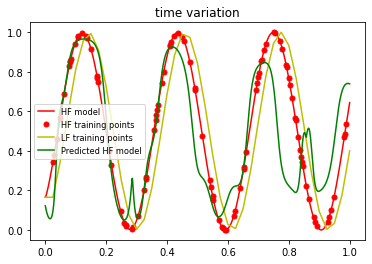

2/2 [==============================] - 0s 7ms/step


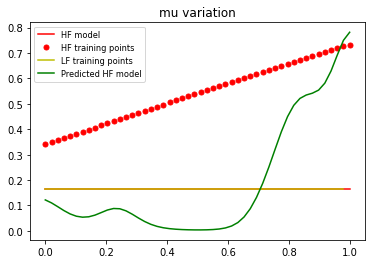

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_5152\3627381309.py:225: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_5152\3627381309.py:227: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_5152\3627381309.py:229: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_5152\3627381309.py:231: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 9  ********************
********************  # Diff: = 5  ********************


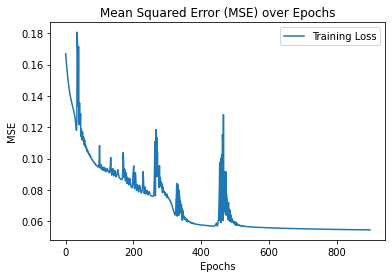

15/15 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.04776563218480776
R^2: 0.5498349538728047
157/157 [==============================] - 0s 2ms/step


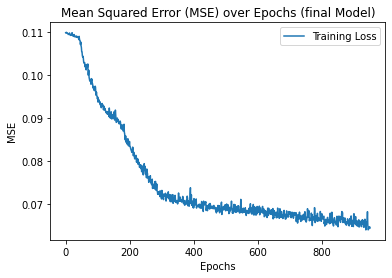

1252/1252 [==============================] - 3s 2ms/step
Elapsed time:  163.4194022999145

HF Model:
Test MSE: 0.05894317893369125
R^2: 0.4767276640459919
26/26 [==============================] - 0s 2ms/step


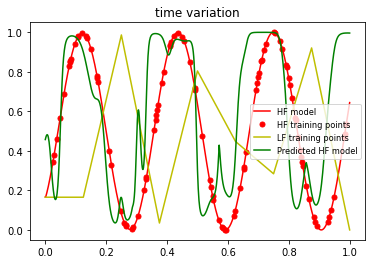

2/2 [==============================] - 0s 4ms/step


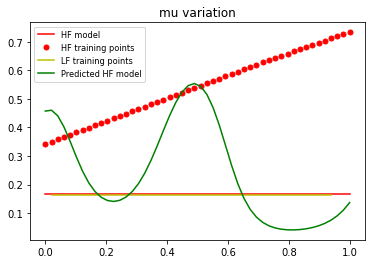

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_5152\3627381309.py:225: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_5152\3627381309.py:227: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_5152\3627381309.py:229: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_5152\3627381309.py:231: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

   Discretization       R2
0             0.0  0.96641
1             5.0  0.57143
2            10.0  0.51931
3            50.0  0.47673
   Discretization      MSE
0             0.0  0.00378
1             5.0  0.04828
2            10.0  0.05415
3            50.0  0.05894


In [38]:
test_mse_HF_list = []
test_mse_LF_list = []

r2_HF_list = []
r2_LF_list = []


#############à
for m in range(len(Discretizations)):
    for d in range(len(diffusion)):
        for r in range(len(Discr)):
            file_name= os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_LF_46"+"_d"+str(diffusion[d])+"_t"+str(Discretizations[m])+".mat")
            #file_name="Diffusion\DATA\reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
            (reaction_LF_test, U_LF_test, t_LF_test) = import_data(file_name)
            t_LF_test=t_LF_test.T
            
            U_LF_test = U_LF_test[
            :,
            :,
            int(4*(Discr[r]-1)/9),
            int(4*(Discr[r]-1)/9)
            ]
            
            
            #U_LF_test = U_LF_test[
            #:,
            #:,
            #int(4*(Discretizations[m]-1)/9),
            #int(4*(Discretizations[m]-1)/9)
            #]
            
            reaction_LF_test = normalization(reaction_LF_test)
            t_LF_test = normalization(t_LF_test)
            U_LF_test = normalization(U_LF_test)        
        
            print(
            f"********************  # Nb. nodes = {t_LF_test.shape[0]}  ********************"
            )
            
            ######### DATASET
            L=np.minimum(Nlf,t_LF_test.shape[0])
            permutation1 = np.random.permutation(len(reaction_LF_test))
            permutation2 = np.random.permutation(len(t_LF_test))
            reaction_LF = reaction_LF_test[permutation1][0:L]    # problema di consistenza qui: non stai confrontando stesso numero di dati, ma è cosairreparabile se non creando nuovo dataset
            t_LF = t_LF_test[permutation2][0:L]
            
            grid1, grid2 = np.meshgrid(reaction_LF, t_LF)
            reaction_LF = np.column_stack((grid1.ravel(), grid2.ravel()))   # <--------
            reaction_LF_test = np.array(list(product(reaction_LF_test.flatten(), t_LF_test.flatten())))
            
            #
            reaction_LF=np.c_[reaction_LF, np.abs(np.sin(3.5*np.pi*reaction_LF[:, 1])),np.ones(reaction_LF.shape[0])]
            reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(3.5*np.pi*reaction_LF_test[:, 1])),np.ones(reaction_LF_test.shape[0])]
            #
            
            p1, p2 = np.meshgrid(permutation1[0:L], permutation2[0:L])
            permutation = np.column_stack((p1.ravel(), p2.ravel()))
            U_train_LF = U_LF_test[permutation[:,0],permutation[:,1]]
            row, col = U_LF_test.shape
            index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
            comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
            U_LF_test = U_LF_test.flatten()[comb]
            #######      

            
            print(
            f"********************  # Diff: = {diffusion[d]}  ********************"
            )
            
            ##########################       FIRST NN: NN_LF     ##########################
            K.clear_session()
            bestLF_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 
            
            modelLF = getModel(bestLF_params, "LF")  # ann_functions
            histLF = modelLF.fit(
                reaction_LF, U_train_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
            )

            plt.plot(modelLF.history.history['loss'][100:], label='Training Loss')
            plt.title('Mean Squared Error (MSE) over Epochs')
            plt.xlabel('Epochs')
            plt.ylabel('MSE')
            plt.legend()
            plt.show()

            ULF = modelLF.predict(reaction_LF_test)

            U_LF_list.append(ULF)
            print("\nLF Model:")
            
            test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
            test_mse_LF_list.append(test_mse)
            print(f"Test MSE: {test_mse}")

            r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
                np.square(U_LF_test - np.mean(U_LF_test))
            )
            r2_LF_list.append(r_2)
            print(f"R^2: {r_2}")
            
            ### SECOND NN#####################
            start = perf_counter()
            reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
            reaction_test_in = np.concatenate(
            (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
            )   # <- TEST INPUT for the second NN: NN_HF

            reaction_train_help = modelLF.predict(reaction_HF)[
                :, 0
            ]  # f_LF(mu_hf_train)
            reaction_final = np.concatenate(
            (reaction_HF, reaction_train_help.reshape(-1,1)),axis=1
            )  # <- TRAINING INPUT for the second NN: NN_HF

            name = "2step"
            K.clear_session()
            # best parameters obtained by HPO:

            best_params = {
                "kernel_init": "uniform",
                "l2weight": 0.0002588943618918075,
                "lr": 0.005,
                "nodes": 64.0,
                "opt": "Adam",
            }
            
            
            finalModel = getModel(
                best_params, name
            )  # final model chosen according to the best paramters
            hist = finalModel.fit(
                reaction_final,
                U_HF,
                validation_data=(reaction_test_in, U_HF_test),
                epochs=NepoHF,
                batch_size=n_HF,
                verbose=0,
                validation_freq=20,
            )

            plt.plot(finalModel.history.history['loss'][50:], label='Training Loss')
            plt.title('Mean Squared Error (MSE) over Epochs (final Model)')
            plt.xlabel('Epochs')
            plt.ylabel('MSE')
            plt.legend()
            plt.show()

            UHF = finalModel.predict(reaction_test_in)
            U_HF_list.append(UHF)

            stop = perf_counter()
            elapsed = stop - start
            print("Elapsed time: ", elapsed)
            print("\nHF Model:")

            test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
            test_mse_HF_list.append(test_mse)
            print(f"Test MSE: {test_mse}")

            r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
                np.square(U_HF_test - np.mean(U_HF_test))
            )
            r2_HF_list.append(r2_HF)
            print(f"R^2: {r2_HF}")
            
            ### plot
            
            index_order=np.argsort(reaction_test_in[:,0])
            index_order_LF=np.argsort(reaction_LF[:,0])   

            plt.figure()
            mask1_test=np.where(reaction_test_in[:,0]==reaction_test_in[:,0][index_order[2]])
            mask1=np.where(reaction_final[:,0]==np.min(reaction_final[:,0]))
            mask1_LF=np.where(reaction_LF[:,0]==reaction_LF[:,0][index_order_LF[2]])
            order=np.argsort(reaction_LF[mask1_LF,1])
    # plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
    # plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
            plt.plot(reaction_test_in[mask1_test,1].T, U_HF_test[mask1_test], "r-", linewidth=1.5, label="HF model")
            plt.plot(reaction_final[mask1,1].T, U_HF[mask1], "ro", markersize=5, label="HF training points")
            plt.plot(reaction_LF[mask1_LF,1].T[order[0,:]], U_train_LF[mask1_LF][order[0,:]], "y-", markersize=5, label="LF training points")
            plt.plot(
            reaction_test_in[mask1_test, 1].T,
            finalModel.predict(reaction_test_in[mask1_test, :][0,:,:]),
            "g-",
            markersize=5,
            label="Predicted HF model",
            )

            plt.legend(prop={"size": 8.3})  
            plt.title("time variation")
            plt.show()

            index_order=np.argsort(reaction_test_in[:,1])
            index_order_LF=np.argsort(reaction_LF[:,1])  

            plt.figure()
            mask2_test=np.where(reaction_test_in[:,1]==reaction_test_in[:,1][index_order[2]])
            mask2=np.where(reaction_final[:,1]==np.min(reaction_final[:,1]))   
            mask2_LF=np.where(reaction_LF[:,1]==reaction_LF[:,1][index_order_LF[2]])
            order=np.argsort(reaction_LF[mask2_LF,0])
    # plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
    # plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
            plt.plot(reaction_test_in[mask2_test,0].T, U_HF_test[mask2_test], "r-", linewidth=1.5, label="HF model")
            plt.plot(reaction_final[mask2,0].T, U_HF[mask2], "ro", markersize=5, label="HF training points")
            plt.plot(reaction_LF[mask2_LF,0].T[order[0,:]][:,0], U_train_LF[mask2_LF][order[0,:]], "y-", markersize=5, label="LF training points")
            plt.plot(
            reaction_test_in[mask2_test, 0].T,
            finalModel.predict(reaction_test_in[mask2_test, :][0,:,:]),
            "g-",
            markersize=5,
            label="Predicted HF model",
            )
            #print(U_HF_test.shape)
            #print(U_HF_test[mask2_test].shape)
            #print(U_HF[mask2])
            plt.legend(prop={"size": 8.3})
            plt.title("mu variation")
            plt.show()

            new = {'Discretization': Discretizations[m], 'R2': r2_LF_list[-1]}
            r2_LF_df=r2_LF_df.append(new, ignore_index=True)
            new = {'Discretization': Discretizations[m], 'R2': r2_HF_list[-1]}
            r2_HF_df=r2_HF_df.append(new, ignore_index=True)
            new = {'Discretization': Discretizations[m], 'MSE': test_mse_LF_list[-1]}
            mse_LF_df=mse_LF_df.append(new, ignore_index=True)
            new = {'Discretization': Discretizations[m], 'MSE': test_mse_HF_list[-1]}
            mse_HF_df=mse_HF_df.append(new, ignore_index=True)
            
            if not r2_HF_list[:-1]:
                save_model(modelLF,"modelLF2NN.h5")
                save_model(finalModel,"finalModel2NN.h5")
            elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
                save_model(modelLF,"modelLF2NN.h5")
                save_model(finalModel,"finalModel2NN.h5")
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))


## Save the output

In [39]:
os.makedirs("MF_LF_150_5000_HF_75_4000_2NNt_multiparam")

r2_HF_df.to_csv(
    "./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)

FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: 'MF_LF_150_5000_HF_75_4000_2NNt_multiparam'